# Part 2: Gradient Descent + PyTorch Basics
**⏱ This section takes approximately 30 minutes.**

---

## Scenario: Wednesday — How Networks Actually LEARN

Yesterday Sarah trained an MLP with one line: `MLPClassifier().fit(X, y)`. Today she opens the hood. What's happening inside that `.fit()` call?

Two concepts to internalise:
1. **Gradient descent** — the optimisation algorithm. Move parameters in the direction of the negative gradient of the loss. Repeat.
2. **PyTorch** — the framework that makes this concrete. Autograd computes gradients automatically; you write the model + the training loop.

**By the end of this notebook you will be able to:**
- Visualise gradient descent on a simple 1D / 2D loss surface
- Write a basic PyTorch model with `nn.Module`
- Use `loss.backward()` to compute gradients automatically
- Write a manual gradient descent step
- Train your first PyTorch model on Sarah's session data

In [1]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

import torch
import torch.nn as nn
import torch.optim as optim

torch.set_num_threads(1)  # macOS: prevent OpenMP segfaults on PyTorch generation cells

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (11, 5)

# Seed everything for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print(f"✅ PyTorch {torch.__version__} ready")

✅ PyTorch 2.12.0 ready


## Step 1 — Gradient descent on a 1D problem

Imagine a loss function `L(w) = (w - 3)²`. The minimum is at w = 3. Gradient descent finds it by following the slope downhill.

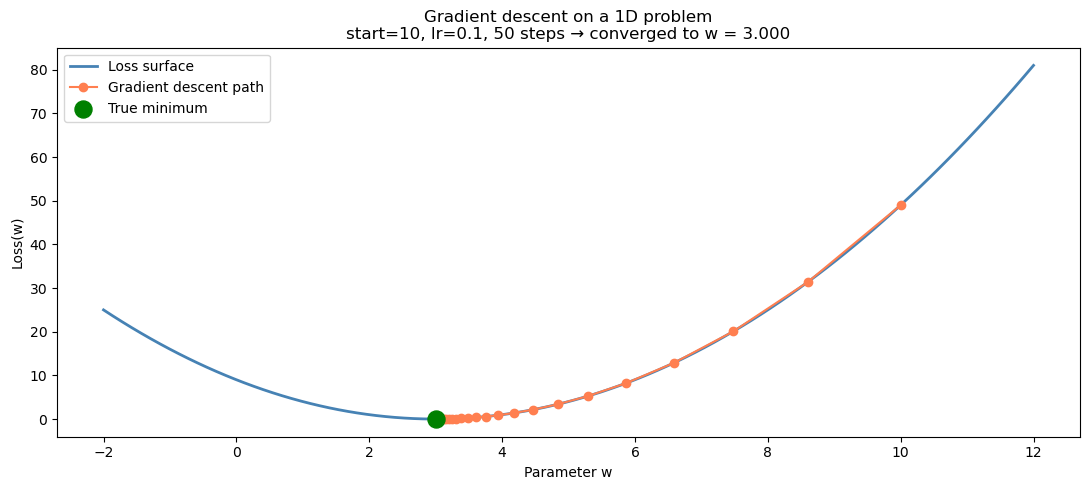

Started at w = 10, took 50 steps with learning rate 0.1
Final w = 3.0001  (true minimum is 3)
Each step moved toward 3 by a smaller amount (gradient shrinks as we approach the minimum).


In [2]:
# The function and its gradient
def loss(w):
    return (w - 3) ** 2

def grad(w):
    return 2 * (w - 3)   # derivative of (w-3)^2

# Start at w = 10 (far from the minimum)
w = 10.0
lr = 0.1   # learning rate
history = [w]

for step in range(50):
    g = grad(w)
    w = w - lr * g
    history.append(w)

# Plot the descent
w_range = np.linspace(-2, 12, 100)
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(w_range, loss(w_range), color="steelblue", linewidth=2, label="Loss surface")
ax.plot(history, [loss(w) for w in history], "o-", color="coral",
        markersize=6, linewidth=1.5, label="Gradient descent path")
ax.scatter([3], [0], color="green", s=150, zorder=5, label="True minimum")
ax.set_xlabel("Parameter w")
ax.set_ylabel("Loss(w)")
ax.set_title(f"Gradient descent on a 1D problem\nstart=10, lr=0.1, 50 steps → converged to w = {w:.3f}")
ax.legend()
plt.tight_layout(); plt.show()

print(f"Started at w = 10, took 50 steps with learning rate 0.1")
print(f"Final w = {w:.4f}  (true minimum is 3)")
print(f"Each step moved toward 3 by a smaller amount (gradient shrinks as we approach the minimum).")

### 💡 What you should notice

- **The path is curved** — large steps far from the minimum, small steps near it. That's because the gradient shrinks as you approach the minimum.
- **The learning rate controls step size.** With lr=0.1, we converge smoothly. With lr=1.5 or higher, we'd OVERSHOOT and diverge.
- **This is the SAME algorithm** that trains neural networks. The only difference: neural networks have thousands of parameters instead of one.

## ⏸️ Pause and Predict

What happens if we set the learning rate way too high (say 1.5)?
What happens if we set it way too low (say 0.001)?

> *Sample answers:*
> - **lr too high (1.5):** the step jumps OVER the minimum to the other side, then back, then overshoots more. Oscillates and DIVERGES.
> - **lr too low (0.001):** takes tiny steps. Converges eventually but extremely slowly. Wastes compute.
> - **Right lr (0.01-0.1 typically):** smooth, fast convergence. Adam optimiser ADAPTS lr per parameter, removing this manual tuning headache.

## Step 2 — PyTorch tensors and autograd

PyTorch's killer feature: AUTOGRAD. You don't compute gradients by hand — PyTorch builds a computation graph automatically and computes gradients via backprop.

Let's compute `loss(w)` and let PyTorch tell us the gradient.

In [3]:
# Create a tensor with gradients tracked
w = torch.tensor([10.0], requires_grad=True)

# Compute loss — PyTorch tracks every operation
loss_value = (w - 3) ** 2
print(f"Loss at w=10: {loss_value.item():.2f}")

# Backward pass — PyTorch computes the gradient
loss_value.backward()
print(f"PyTorch says the gradient at w=10 is: {w.grad.item():.2f}")
print(f"(By hand: derivative of (w-3)² at w=10 is 2*(10-3) = 14.  ✓)")
print()
print("This is autograd. PyTorch tracks operations during the forward pass,")
print("then computes gradients by applying the chain rule during the backward pass.")

Loss at w=10: 49.00
PyTorch says the gradient at w=10 is: 14.00
(By hand: derivative of (w-3)² at w=10 is 2*(10-3) = 14.  ✓)

This is autograd. PyTorch tracks operations during the forward pass,
then computes gradients by applying the chain rule during the backward pass.


## Step 3 — A manual training loop in PyTorch

Now train the same 1D problem with PyTorch — using autograd.

In [4]:
w = torch.tensor([10.0], requires_grad=True)
lr = 0.1
history_torch = [w.item()]

for step in range(50):
    # Forward pass: compute loss
    loss_value = (w - 3) ** 2

    # Backward pass: compute gradient
    loss_value.backward()

    # Manual gradient descent step (NO optimiser yet)
    with torch.no_grad():    # don't track this operation in the graph
        w -= lr * w.grad
        w.grad.zero_()       # IMPORTANT: clear the gradient for the next step

    history_torch.append(w.item())

print(f"Started at w = 10")
print(f"After 50 steps: w = {w.item():.4f}")
print(f"True minimum: 3.0")
print()
print("Notice the THREE PyTorch idioms:")
print("  1. .backward()    → compute gradients")
print("  2. with torch.no_grad(): w -= lr * w.grad  → update parameter")
print("  3. w.grad.zero_()  → CLEAR the gradient (otherwise it accumulates)")

Started at w = 10
After 50 steps: w = 3.0001
True minimum: 3.0

Notice the THREE PyTorch idioms:
  1. .backward()    → compute gradients
  2. with torch.no_grad(): w -= lr * w.grad  → update parameter
  3. w.grad.zero_()  → CLEAR the gradient (otherwise it accumulates)


## Step 4 — A PyTorch optimiser handles the update for you

Doing the parameter update by hand is tedious. PyTorch's `optimizer.step()` does it in one line.

In [5]:
w = torch.tensor([10.0], requires_grad=True)
optimizer = optim.SGD([w], lr=0.1)

for step in range(50):
    optimizer.zero_grad()         # equivalent to w.grad.zero_()
    loss_value = (w - 3) ** 2
    loss_value.backward()
    optimizer.step()              # equivalent to w -= lr * w.grad

print(f"Final w = {w.item():.4f}  (with optimizer.step() — much cleaner)")
print()
print("THE PYTORCH TRAINING LOOP (memorise these 5 lines):")
print("  for batch in data:")
print("    optimizer.zero_grad()    # clear old gradients")
print("    loss = criterion(model(x), y)    # forward pass + loss")
print("    loss.backward()           # backward pass (autograd)")
print("    optimizer.step()          # update parameters")

Final w = 3.0001  (with optimizer.step() — much cleaner)

THE PYTORCH TRAINING LOOP (memorise these 5 lines):
  for batch in data:
    optimizer.zero_grad()    # clear old gradients
    loss = criterion(model(x), y)    # forward pass + loss
    loss.backward()           # backward pass (autograd)
    optimizer.step()          # update parameters


## Step 5 — Now build a real model with `nn.Module`

For multi-parameter models we use `nn.Module`. Subclass it, define layers in `__init__`, and the forward pass in `forward()`.

In [6]:
class SimpleMLP(nn.Module):
    def __init__(self, n_features, hidden=16):
        super().__init__()
        self.fc1 = nn.Linear(n_features, hidden)   # Linear = fully-connected layer
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden, 1)            # 1 output (binary classification)

    def forward(self, x):
        x = self.fc1(x)        # input → 16 features
        x = self.relu(x)       # non-linear activation
        x = self.fc2(x)        # → 1 logit
        return x

model = SimpleMLP(n_features=9, hidden=16)
print(model)
print()
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

SimpleMLP(
  (fc1): Linear(in_features=9, out_features=16, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=16, out_features=1, bias=True)
)

Total parameters: 177


## Step 6 — Train on Sarah's session data (manual loop, no DataLoader yet)

We'll use full-batch gradient descent for simplicity. Tomorrow we move to mini-batches with DataLoader.

In [7]:
# Load and preprocess session data
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("data/northstar_sessions.csv")
y = df["completed"].values
X = df.drop(columns=["session_id", "completed"]).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42,
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train_t = torch.tensor(X_train_s, dtype=torch.float32)
y_train_t = torch.tensor(y_train,    dtype=torch.float32)
X_test_t  = torch.tensor(X_test_s,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,     dtype=torch.float32)

print(f"X_train shape: {X_train_t.shape}")
print(f"X_test shape:  {X_test_t.shape}")

X_train shape: torch.Size([6400, 9])
X_test shape:  torch.Size([1600, 9])


In [8]:
# Initialise model, loss, optimiser
torch.manual_seed(42)
model = SimpleMLP(n_features=X_train_t.shape[1], hidden=16)
criterion = nn.BCEWithLogitsLoss()    # binary cross-entropy from logits — numerically stable
optimizer = optim.SGD(model.parameters(), lr=0.05)

# Full-batch training loop
n_epochs = 200
train_losses, test_losses = [], []

for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    logits = model(X_train_t).squeeze(-1)   # (N, 1) → (N,)
    loss = criterion(logits, y_train_t)
    loss.backward()
    optimizer.step()

    # Eval
    model.eval()
    with torch.no_grad():
        test_logits = model(X_test_t).squeeze(-1)
        test_loss = criterion(test_logits, y_test_t).item()

    train_losses.append(loss.item())
    test_losses.append(test_loss)

# Final accuracy + AUC
from sklearn.metrics import accuracy_score, roc_auc_score
test_probs = torch.sigmoid(test_logits).numpy()
test_preds = (test_probs > 0.5).astype(int)
print(f"After {n_epochs} epochs (full-batch SGD):")
print(f"  Final train loss: {train_losses[-1]:.4f}")
print(f"  Final test loss:  {test_losses[-1]:.4f}")
print(f"  Test accuracy:    {accuracy_score(y_test, test_preds):.3f}")
print(f"  Test AUC:         {roc_auc_score(y_test, test_probs):.3f}")

After 200 epochs (full-batch SGD):
  Final train loss: 0.5853
  Final test loss:  0.5952
  Test accuracy:    0.688
  Test AUC:         0.742


## Step 7 — Plot the loss curves

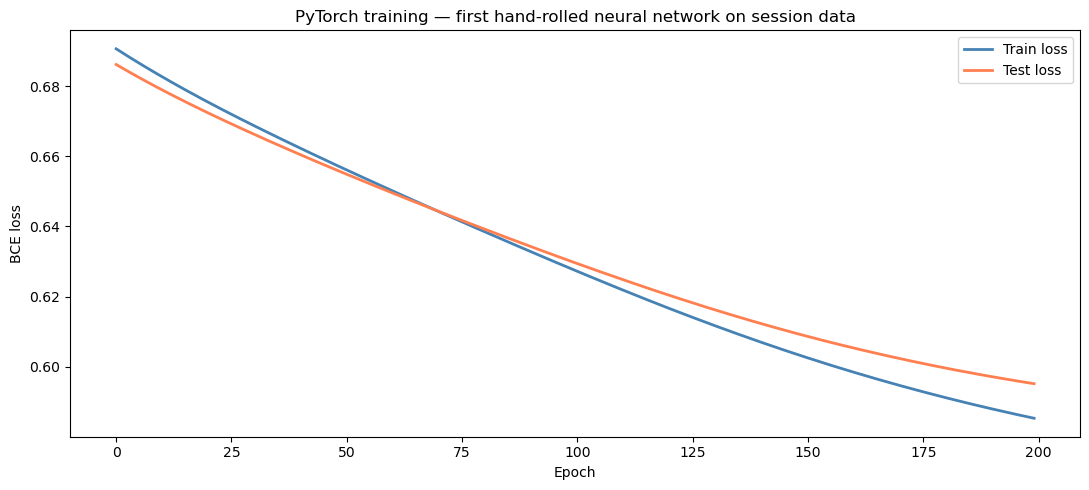

Notice:
  - Train loss decreases steadily — gradient descent is working
  - Test loss tracks train loss closely — no overfitting (yet)
  - Final AUC matches sklearn's MLPClassifier — same algorithm, just hand-rolled


In [9]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(train_losses, label="Train loss", color="steelblue", linewidth=2)
ax.plot(test_losses,  label="Test loss",  color="coral", linewidth=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("BCE loss")
ax.set_title("PyTorch training — first hand-rolled neural network on session data")
ax.legend()
plt.tight_layout(); plt.show()

print("Notice:")
print("  - Train loss decreases steadily — gradient descent is working")
print("  - Test loss tracks train loss closely — no overfitting (yet)")
print("  - Final AUC matches sklearn's MLPClassifier — same algorithm, just hand-rolled")

## ✅ Section Summary

| Step | What we did |
|---|---|
| **Gradient descent on 1D** | Walked downhill on (w-3)² with manual gradient computation |
| **Autograd** | PyTorch computed gradients automatically via `.backward()` |
| **Manual update** | `w -= lr * w.grad` + `w.grad.zero_()` |
| **Optimizer** | `optim.SGD` packages those steps as `optimizer.step()` |
| **`nn.Module` model** | Subclass + `__init__` (layers) + `forward()` (computation) |
| **Trained on session data** | Same AUC as sklearn's MLPClassifier — proves the implementation is correct |

**The 5-line PyTorch training loop you'll use forever:**

```python
for batch in data:
    optimizer.zero_grad()
    loss = criterion(model(x), y)
    loss.backward()
    optimizer.step()
```

---
**Up next → Part 3:** Thursday — full-scale PyTorch training loop with `DataLoader` + mini-batches + Adam + early stopping. The complete pattern that transfers to L08 (CNNs), L09 (NLP), L10 (transformers).
Open `04_pytorch_training_loop.ipynb`

---

## 🟡 Extension — self-study after class

*Skipping this section will not affect your understanding of later lessons. Come back to it when you have time and want to go deeper.*

## Extension 1 — Visualise gradient descent on a 2D loss surface

For a 2-parameter function, we can plot the loss surface as a contour and watch the descent.

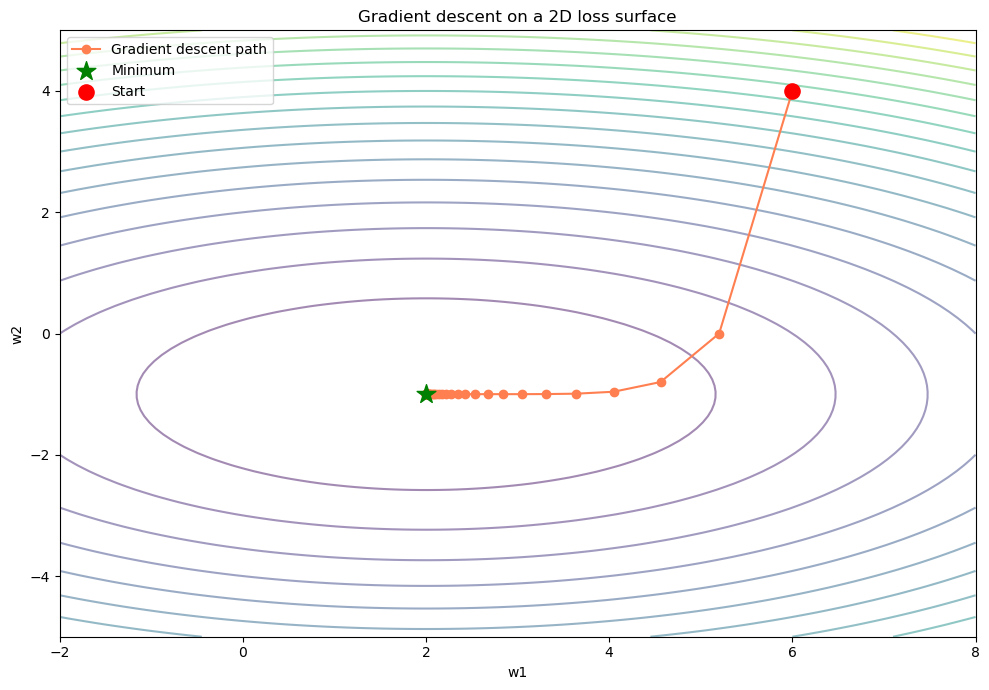

Notice the path is CURVED — the gradient changes direction as you descend.
In neural networks, the loss surface has thousands of dimensions and many local minima/saddles.


In [10]:
# A simple 2D quadratic with two parameters
def loss_2d(w1, w2):
    return (w1 - 2)**2 + 4 * (w2 + 1)**2   # ellipse, minimum at (2, -1)

def grad_2d(w1, w2):
    return np.array([2*(w1 - 2), 8*(w2 + 1)])

# Run gradient descent
pt = np.array([6.0, 4.0])
lr = 0.1
path = [pt.copy()]
for _ in range(50):
    g = grad_2d(*pt)
    pt = pt - lr * g
    path.append(pt.copy())
path = np.array(path)

# Plot
w1_range = np.linspace(-2, 8, 100)
w2_range = np.linspace(-5, 5, 100)
W1, W2 = np.meshgrid(w1_range, w2_range)
Z = loss_2d(W1, W2)

fig, ax = plt.subplots(figsize=(10, 7))
contour = ax.contour(W1, W2, Z, levels=20, cmap="viridis", alpha=0.5)
ax.plot(path[:, 0], path[:, 1], "o-", color="coral", markersize=6, linewidth=1.5,
        label="Gradient descent path")
ax.scatter([2], [-1], color="green", s=200, zorder=5, marker="*", label="Minimum")
ax.scatter([path[0, 0]], [path[0, 1]], color="red", s=120, zorder=5, label="Start")
ax.set_xlabel("w1"); ax.set_ylabel("w2")
ax.set_title("Gradient descent on a 2D loss surface")
ax.legend()
plt.tight_layout(); plt.show()

print("Notice the path is CURVED — the gradient changes direction as you descend.")
print("In neural networks, the loss surface has thousands of dimensions and many local minima/saddles.")

## Extension 2 — What happens with too-high / too-low learning rates?

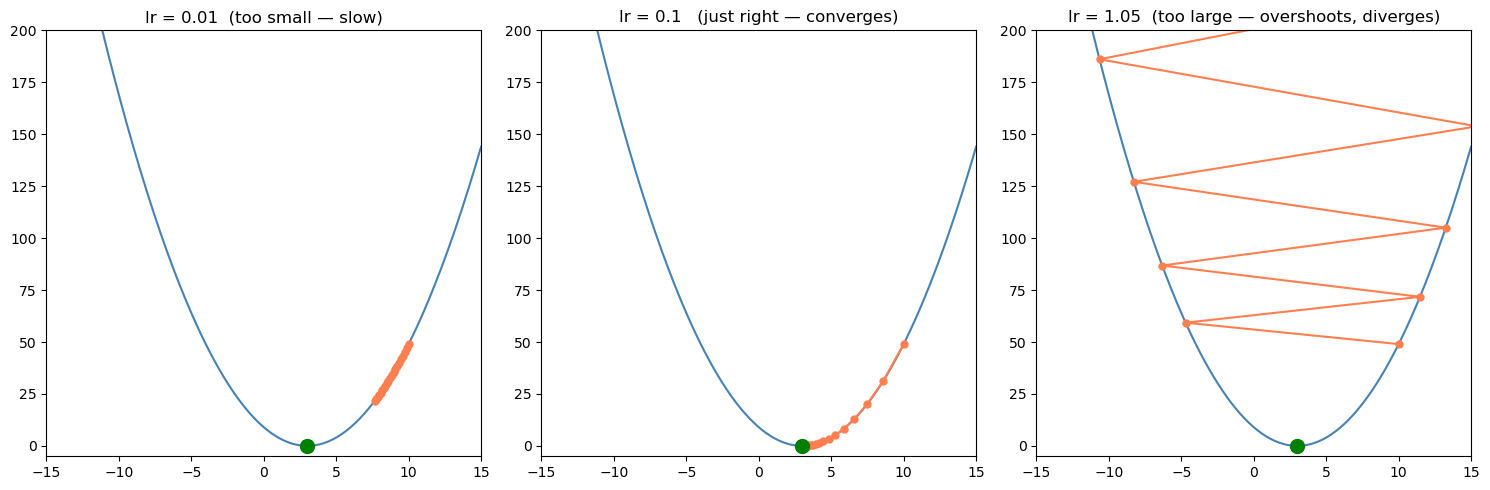

Learning rate is the most important hyperparameter to tune.
Common starting points: 1e-3 (Adam), 1e-2 (SGD with momentum).


In [11]:
def gd_path(start_w, lr, n_steps=20):
    w = start_w
    path = [w]
    for _ in range(n_steps):
        w = w - lr * 2 * (w - 3)
        path.append(w)
    return path

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (lr_val, label) in zip(axes, [
    (0.01, "lr = 0.01  (too small — slow)"),
    (0.1,  "lr = 0.1   (just right — converges)"),
    (1.05, "lr = 1.05  (too large — overshoots, diverges)"),
]):
    path = gd_path(10.0, lr_val)
    w_range = np.linspace(-15, 15, 200)
    ax.plot(w_range, (w_range - 3)**2, color="steelblue", linewidth=1.5)
    ax.plot(path, [(w - 3)**2 for w in path], "o-", color="coral", markersize=5)
    ax.scatter([3], [0], color="green", s=100, zorder=5)
    ax.set_title(label)
    ax.set_xlim(-15, 15)
    ax.set_ylim(-5, 200)

plt.tight_layout(); plt.show()
print("Learning rate is the most important hyperparameter to tune.")
print("Common starting points: 1e-3 (Adam), 1e-2 (SGD with momentum).")